In [1]:
import copy
import sys
import os
import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
# The code is desigend to be run on both CPU and GPU. 
# If cupy is available, it will use GPU for computation, 
# otherwise it will fall back to numpy on CPU.
try:
    import cupy as cp
    a=cp.array([0])
except:
    import numpy as cp

# These directories are used to store the custom modules, data and results. You can change them to your own directories.
code_dir = '/n/data2/hms/neurobio/harvey/siyan/arctic/'
data_dir = f'/n/data2/hms/neurobio/harvey/siyan/data/mesoscope/'
root_dir = f'/n/data2/hms/neurobio/harvey/siyan/arctic/example_results/closed_loop/'

# Load custom modules
os.sys.path.insert(0,code_dir)
from src.Model import RnnModel as rnn
from src.Optimizer import Rls, RlsZeroOutDiagonal
from scripts.Ymaze_simulation.LoadData import load_charlotte_delay
from scripts.Ymaze_simulation.Environment import YMaze
from scripts.Ymaze_simulation.TrainEval_closed_loop import train_closed_loop,evaluation_closed_loop, perturbation_closed_loop

# Load example data session

In [2]:
"""
Load data (neural and behavioral) and set up training and testing trials for cross validation. 
"""
filename = 'CA63/190703/'
cv_fold = 0

result_dir = root_dir + filename + 'cv%d/' %cv_fold
if not os.path.exists(result_dir):
    os.makedirs(result_dir)

delay, binary_labels, frame_trial, activity, behavior=load_charlotte_delay(data_dir, filename)
n_neuron = activity.shape[0]
n_frame = activity.shape[1]
n_trial = binary_labels.shape[1]
cor_trial_idxes=np.where(binary_labels[2]==1)[0]
n_cor_trials=cor_trial_idxes.shape[0]
#transfer data to cuda
cues=cp.array(binary_labels[0])
activity = cp.array(activity)
activity[activity>=1]=1-1e-4
behavior = cp.array(behavior)
behavior[cp.isnan(behavior)] = 0
frame_trial = cp.array(frame_trial)

# setup cross validation
n_fold=5
try:
    perm_trial_idxes=np.load(root_dir + filename + 'perm_trial_idxes.npy')
except:
    perm_trial_idxes = np.arange(n_cor_trials)
    np.random.shuffle(perm_trial_idxes)
    np.save(root_dir + filename + 'perm_trial_idxes.npy',perm_trial_idxes)
cv_bins = np.ceil(np.linspace(0, n_cor_trials, n_fold + 1)).astype('int')
test_trials = np.zeros(n_cor_trials, dtype='bool')
test_trials[perm_trial_idxes[cv_bins[cv_fold]:cv_bins[cv_fold + 1]]] = 1
train_trials = ~test_trials
test_trial_idxes = cor_trial_idxes[test_trials]
train_trial_idxes = cor_trial_idxes[train_trials]
np.save(result_dir + 'train_trial_idxes.npy', train_trial_idxes)

# Closed-loop training and evaluation

In [3]:
"""
The RNN model will be trained and evaluated in closed-loop interaction with a Y-maze environment.
Each RNN unit is fit to one real neuron, and the RNN collective is trained to output the velocity of the animal.
A gradient-free learning algorithm (recursive least square, RLS) is used to train the input, recurrent and output weights of the RNN.
"""
lr_out= 1 #learning rate of output weights
lr_in= 5 #learning rate of input and recurrent weights
noise= 0.1 #noise level added to the RNN activity during training, which can help with generalization.
n_epoch = 30 #number of training epochs, each epoch contains one pass through all training trials.

#initialize objects
net=rnn(dtData=0.186, dt=0.0093, tau=0.1, g=0, N=n_neuron,
        phi='modifiedtanh',input_dim=11,output_dim=3,observation_dim=5)
env=YMaze(delay)
optim_outputs=Rls(M=n_neuron,lr=lr_out)
optim_inputs=RlsZeroOutDiagonal(M=n_neuron+11,N=n_neuron,reg_ratio=500,lr=lr_in)

#train loop
t0=time.perf_counter()
J_neu,J_beh = train_closed_loop(net,env,
                                optim_inputs,optim_outputs,
                                cues,activity,behavior,frame_trial,
                                train_trial_idxes,
                                cur_noise=noise,n_epoch=n_epoch)
elapsed = time.perf_counter() - t0
print(f"Last run: 100% ({n_epoch}/{n_epoch}) in {elapsed:.2f} s")

cp.save(result_dir + f'Jneu_{n_epoch}.npy', J_neu)
cp.save(result_dir + f'Jbeh_{n_epoch}.npy', J_beh)

100%|██████████| 30/30 [6:03:06<00:00, 726.22s/it]  

Last run: 100% (30/30) in 21786.56 s


In [ ]:
# This cell takes about 10 minutes to run on GPU
R_eval, beh_eval, frame_trial_eval = evaluation_closed_loop(net,env,
                                                            cues, activity, behavior,frame_trial,
                                                            cor_trial_idxes,
                                                            cur_noise=0)
cp.save(result_dir + 'R_0.0.npy', R_eval)
cp.save(result_dir + 'beh_output_0.0.npy', beh_eval)
np.save(result_dir + 'frame_trial_eval_0.0.npy', np.array(frame_trial_eval))

# Visualize trial-by-trial lateral velocity

In [3]:
from scripts.Ymaze_analyses.Utils import model_correctness
beh_model=np.load(result_dir + 'beh_output_0.0.npy')
frame_trial_eval=np.load(result_dir + 'frame_trial_eval_0.0.npy')
choices=binary_labels[1,cor_trial_idxes]
correct_m=model_correctness(beh_model,frame_trial_eval,cor_trial_idxes,choices)

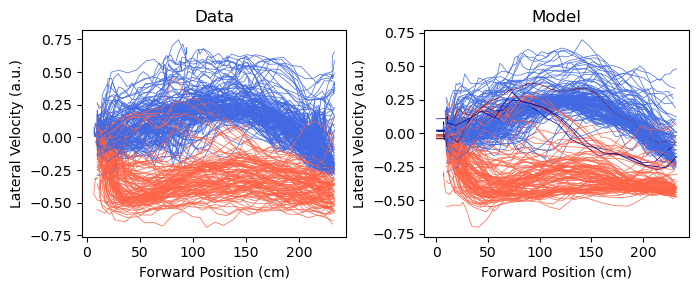

In [4]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
colors=[['darkblue','royalblue'],['darkred','tomato']]
for idx, trial_index in enumerate(cor_trial_idxes):
    ax[0].plot(cp.asnumpy(behavior[3, frame_trial == trial_index]), 
             -1*cp.asnumpy(behavior[1, frame_trial == trial_index]),
             c=colors[binary_labels[1][trial_index]][1],lw=0.5)
    ax[1].plot(cp.asnumpy(beh_model[3, np.array(frame_trial_eval) == trial_index]), 
             -1*cp.asnumpy(beh_model[1, np.array(frame_trial_eval) == trial_index]),
             c=colors[binary_labels[1][trial_index]][int(correct_m[idx])],lw=0.5)
ax[0].set_title('Data')
ax[0].set_xlabel('Forward Position (cm)')
ax[0].set_ylabel('Lateral Velocity (a.u.)')
ax[1].set_title('Model')
ax[1].set_xlabel('Forward Position (cm)')
ax[1].set_ylabel('Lateral Velocity (a.u.)')
plt.tight_layout()

# Perturbation along CD reveals chaotic attractor dynamics

In [5]:
pos = 80 # the forward position in the maze where a transient perturbation occurs, in cm. 
n_epoch = 30 

# define CD
from scripts.Ymaze_analyses.Utils import binning_maze
legit_trial_idxes=cor_trial_idxes[correct_m]
choices_cor=choices[correct_m]
R_model=np.load(result_dir + 'R_0.0.npy')
R_binned_model=binning_maze(R_model,5,235,46,
                            legit_trial_idxes,beh_model[3],frame_trial_eval)
cd=np.mean(R_binned_model[choices_cor==1,:,:],axis=0)-\
   np.mean(R_binned_model[choices_cor==0,:,:],axis=0)
cd=cp.array(cd)

J_neu=cp.load(result_dir + f'Jneu_{n_epoch}.npy')
J_beh=cp.load(result_dir + f'Jbeh_{n_epoch}.npy')

#initialize objects
net=rnn(dtData=0.186, dt=0.0093, tau=0.1, g=0, N=n_neuron,
        phi='modifiedtanh',input_dim=11,output_dim=3,observation_dim=5)
net.set_params(J_neu, J_beh)
env=YMaze(delay)

norm = 0.1 # the magnitude of the perturbation, which is scaled by the difference between mean left and right CD projections
R_perturb_01, beh_output_perturb_01, frame_trial_perturb_01 = perturbation_closed_loop(net,env,
                                                                            cues, R_model, beh_model,frame_trial_eval,
                                                                            legit_trial_idxes,
                                                                            pos, norm,cd)
norm = 0.3 
R_perturb_03, beh_output_perturb_03, frame_trial_perturb_03 = perturbation_closed_loop(net,env,
                                                                            cues, R_model, beh_model,frame_trial_eval,
                                                                            legit_trial_idxes,
                                                                            pos, norm,cd)
norm = 0.5 
R_perturb_05, beh_output_perturb_05, frame_trial_perturb_05 = perturbation_closed_loop(net,env,
                                                                            cues, R_model, beh_model,frame_trial_eval,
                                                                            legit_trial_idxes,
                                                                            pos, norm,cd)

In [6]:
#Model projection
cd=cp.asnumpy(cd)
cd=cd/np.linalg.norm(cd,axis=0)[np.newaxis,:]
cd_mid=(np.mean(R_binned_model[choices_cor==1,:,:],axis=0)+np.mean(R_binned_model[choices_cor==0,:,:],axis=0))/2
cd_proj_model=np.einsum('int,nt->it',R_binned_model-cd_mid[np.newaxis,:,:],cd)*(-1)
cd_proj_model=cp.asnumpy(cd_proj_model)
R_binned_perturb_01=binning_maze(R_perturb_01,5,235,46,
                            legit_trial_idxes,beh_output_perturb_01[3],frame_trial_perturb_01)
R_binned_perturb_03=binning_maze(R_perturb_03,5,235,46,
                            legit_trial_idxes,beh_output_perturb_03[3],frame_trial_perturb_03)
R_binned_perturb_05=binning_maze(R_perturb_05,5,235,46,
                            legit_trial_idxes,beh_output_perturb_05[3],frame_trial_perturb_05)
cd_proj_perturb_05=np.einsum('int,nt->it',R_binned_perturb_05-cd_mid[np.newaxis,:,:],cd)*(-1)
cd_proj_perturb_05=cp.asnumpy(cd_proj_perturb_05)

The below cell replicates Fig. 2 a,b,c in the paper

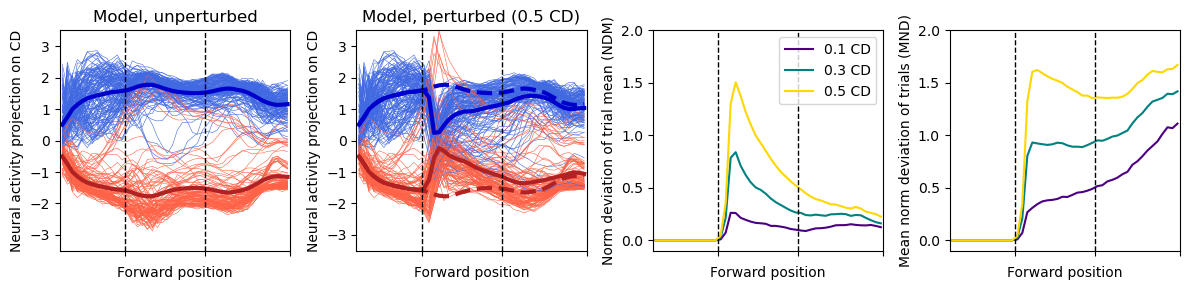

In [7]:
fig,ax=plt.subplots(1,4,figsize=(12,3))
xs=np.arange(7.5,235,5)
delay_tick=delay
turn_tick=150
end_tick=235
xticks=[delay_tick,turn_tick,end_tick]
colors=['royalblue','tomato']
for i in range(legit_trial_idxes.shape[0]):
    ax[0].plot(xs,cd_proj_model[i],c=colors[choices_cor[i]],lw=0.4,clip_on=False)
    ax[1].plot(xs,cd_proj_perturb_05[i],c=colors[choices_cor[i]],lw=0.4,clip_on=False)
ax[0].plot(xs,np.mean(cd_proj_model[choices_cor==0],axis=0),c='mediumblue',lw=3)
ax[0].plot(xs,np.mean(cd_proj_model[choices_cor==1],axis=0),c='firebrick',lw=3)
ax[1].plot(xs,np.mean(cd_proj_perturb_05[choices_cor==0],axis=0),c='mediumblue',lw=3)
ax[1].plot(xs,np.mean(cd_proj_perturb_05[choices_cor==1],axis=0),c='firebrick',lw=3)
ax[1].plot(xs,np.mean(cd_proj_model[choices_cor==0],axis=0),c='mediumblue',lw=3,ls='--')
ax[1].plot(xs,np.mean(cd_proj_model[choices_cor==1],axis=0),c='firebrick',lw=3,ls='--')

colors=['indigo','teal','gold']
norm=[0.1, 0.3, 0.5]
R_binned_perturb_all=[R_binned_perturb_01, R_binned_perturb_03, R_binned_perturb_05]
beh_output_perturb_all=[beh_output_perturb_01, beh_output_perturb_03, beh_output_perturb_05]
frame_trial_perturb_all=[frame_trial_perturb_01, frame_trial_perturb_03, frame_trial_perturb_05]
for i in range(3):
    correct_p=model_correctness(beh_output_perturb_all[i],frame_trial_perturb_all[i],legit_trial_idxes,choices_cor)
    trials_R=np.logical_and(choices_cor==1,correct_p==1) 
    trials_L=np.logical_and(choices_cor==0,correct_p==1) # only evaluate trials that are still correct after perturbation.
    NDM = (np.linalg.norm((np.nanmean(R_binned_model[trials_R],axis=0)-np.nanmean(R_binned_perturb_all[i][trials_R],axis=0)),axis=0) +\
        np.linalg.norm((np.nanmean(R_binned_model[trials_L],axis=0)-np.nanmean(R_binned_perturb_all[i][trials_L],axis=0)),axis=0))/2
    MND = np.nanmean(np.linalg.norm(R_binned_model[correct_p]-R_binned_perturb_all[i][correct_p],axis=1),axis=0)
    ax[2].plot(xs,NDM,c=colors[i],label='%.1f CD'%norm[i])
    ax[3].plot(xs,MND,c=colors[i],label='%.1f CD'%norm[i])


for i in [0,1,2,3]:
    ax[i].set_xticks(xticks)
    ax[i].set_xticklabels(['','',''])
    ax[i].axvline(delay_tick,lw=1,linestyle='--',c='k')
    ax[i].axvline(turn_tick,lw=1,linestyle='--',c='k')
    ax[i].set_xlim(5,235)
    ax[i].set_xlabel('Forward position')

ax[0].set_ylabel('Neural activity projection on CD')
ax[1].set_ylabel('Neural activity projection on CD')
ax[2].set_ylabel('Norm deviation of trial mean (NDM)')
ax[3].set_ylabel('Mean norm deviation of trials (MND)')
ax[0].set_ylim(-3.5,3.5)
ax[1].set_ylim(-3.5,3.5)
ax[2].set_ylim(-0.1,2)
ax[3].set_ylim(-0.1,2)
ax[0].set_title('Model, unperturbed')
ax[1].set_title('Model, perturbed (0.5 CD)')
ax[2].legend()

plt.tight_layout()

# Compute largest Lyapunov exponent

In [7]:
#initialize objects
net=rnn(dtData=0.186, dt=0.0093, tau=0.1, g=0, N=n_neuron,
        phi='modifiedtanh',input_dim=11,output_dim=3,observation_dim=5)
env=YMaze(delay)
J_neu=cp.load(result_dir + 'Jneu_30.npy')
J_beh=cp.load(result_dir + 'Jbeh_30.npy')
net.set_params(J_neu,J_beh)

In [ ]:
from scripts.Ymaze_simulation.TrainEval_closed_loop import CLV_closed_loop
CLV_dir=result_dir + 'CLV/'
if not os.path.exists(CLV_dir):
    os.makedirs(CLV_dir)
for n in tqdm(range(50)):
    for repeat in range(20):
        ratios, Qs = CLV_closed_loop(net,env,
                                    cues, activity, behavior,frame_trial,
                                    [cor_trial_idxes[correct_m][n]],
                                    K=1,max_length=100)
        cp.save(CLV_dir + f'ratios_{n}_{repeat}.npy', ratios)
        cp.save(CLV_dir + f'Qs_{n}_{repeat}.npy', Qs)

100%|██████████| 50/50 [1:05:49<00:00, 79.00s/it]


In [ ]:
dt=0.186
filename = 'CA63/190703/'
repeat = 0
result_dir = root_dir + filename + 'cv%d/' %repeat
CLV_dir=result_dir + 'CLV/'
lyapunov=np.full((50,50,20,1),np.nan)#n_trial,t,repeat,n_LE
for n in range(50):
    for repeat in range(20):
        ratios=np.load(CLV_dir+f'ratios_{n}_{repeat}.npy')
        ratios=ratios[1:]
        #start from t=2 to t=50 because the first two steps are usually not stable and can be outliers for the estimation of lyapunov exponent
        tem=np.array([np.sum(np.log(ratios[2:t,:]),axis=0)/((t-2)*dt) for t in np.arange(2,ratios.shape[0])])[:48]
        lyapunov[n,2:tem.shape[0]+2,repeat]=copy.deepcopy(tem)



/home/sz154/rnnenv/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in true_divide
  del sys.path[0]


The figures below replicate Extended Data Fig. 2f (Estimation of largest lyapunov exponent)

/home/sz154/rnnenv/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: Mean of empty slice
  del sys.path[0]


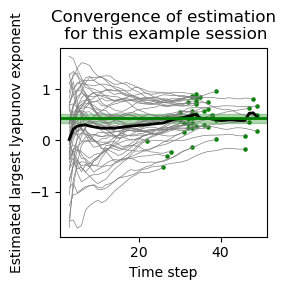

In [28]:
import matplotlib.pyplot as plt
import warnings
LE=[]
fig,ax=plt.subplots(1,1,figsize=(3,3))
for n in range(50):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean=np.nanmean(lyapunov[n,:,:,0],axis=1)
    ax.plot(mean,c='grey',lw=0.5)
    ax.scatter(np.where(~np.isnan(mean))[0][-1],mean[~np.isnan(mean)][-1],c='g',s=5)
    LE.append(mean[~np.isnan(mean)][-1])

mean_curve=np.nanmean(np.nanmean(lyapunov[:,:,:,0],axis=2),axis=0)
ax.plot(mean_curve,c='k',lw=2)
ax.axhline(np.mean(LE),c='g',lw=2)
ax.set_xlabel('Time step')
ax.set_ylabel('Estimated largest lyapunov exponent')
ax.set_title('Convergence of estimation\n for this example session')

from scripts.Ymaze_analyses.Bootstrap import bootstrap_ci,one_sample_bootstrap
ci=bootstrap_ci(np.array(LE),repeat=10000)
ax.axhspan(ci[0],ci[1],color='g',alpha=0.3)
plt.tight_layout()